In [106]:
import pandas as pd
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, callbacks,utils
from imblearn.over_sampling import SMOTE
from collections import Counter
from keras.optimizers import Adam

from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [107]:
df=pd.read_csv("cleaned_ph_updated.csv")
df = df.dropna(subset=['status'])
df.head()

,county,sitename,Date,pm2.5,pm10,no,no2,nox,co,so2,o3,AQI,status
0,NCR,Manila,2014-01-01,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,118.0,emergency
1,NCR,Manila,2014-02-01,32.926035,77.352669,22.808572,57.520162,42.574229,0.793464,19.536258,44.687065,95.0,emergency
2,NCR,Manila,2014-03-01,44.715328,99.910623,34.325038,54.807419,47.240203,1.000999,26.546239,26.985845,124.0,emergency
3,NCR,Manila,2014-04-01,57.845448,138.179877,20.041346,80.667124,53.375489,1.428835,34.518627,48.524207,152.0,emergency
4,NCR,Manila,2014-05-01,31.487699,70.390261,22.100780,56.562426,41.691499,1.120790,17.809835,51.075438,92.0,emergency


In [108]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['status']
X=df[features]
y=df[status]  


In [109]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
num_classes = len(le.classes_)
#y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

In [110]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=True)

In [111]:
sm = SMOTE(random_state=100)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [112]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [113]:
print(X_scaled.shape)

(47664, 8)


In [114]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(8,)), 
    


    # Second Dense layer
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Second Dense layer
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [115]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'

    ]
)

In [116]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_rf_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [117]:
model.fit(
X_scaled, y_train_res,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks)#training nn

Epoch 1/100


149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6262 - loss: 0.9277 - val_accuracy: 0.0062 - val_loss: 1.5611 - learning_rate: 5.0000e-04
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7742 - loss: 0.5598 - val_accuracy: 0.2609 - val_loss: 1.2138 - learning_rate: 5.0000e-04
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8306 - loss: 0.4394 - val_accuracy: 0.4131 - val_loss: 1.0310 - learning_rate: 5.0000e-04
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8672 - loss: 0.3578 - val_accuracy: 0.5927 - val_loss: 0.8384 - learning_rate: 5.0000e-04
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8873 - loss: 0.3054 - val_accuracy: 0.7194 - val_loss: 0.6941 - learning_rate: 5.0000e-04
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9058 - loss: 0.2650 - val_accuracy: 0.8333 - val_loss: 0.5741 - learning_rate: 5.0000e-04
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.916

In [124]:
best_model=tf.keras.models.load_model("best_model_rf_classifier.keras")
nn_predictions = best_model.predict(X_scaled)
y_pseudo_train = np.argmax(nn_predictions, axis=1)

# 2. Train the Random Forest on the tabular data using the NN's pseudo-labels
rf_distilled = RandomForestClassifier(n_estimators=300,
                                      min_samples_split=7,
                                      min_samples_leaf=5,
                                      max_features="sqrt",
                                      max_depth=25,
                                      bootstrap=True)
rf_distilled.fit(X_scaled, y_pseudo_train)

# 3. Scale and prepare your raw test subset
X_test_scaled = scaler.transform(X_test)

# 4. Predict using the distilled Random Forest model
y_pred_rf = rf_distilled.predict(X_test_scaled)

print("--- Distilled Random Forest Performance (Normal NN Teacher) ---")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

1490/1490 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
--- Distilled Random Forest Performance (Normal NN Teacher) ---
                               precision    recall  f1-score   support

            acutely unhealthy       0.99      0.98      0.99      1977
                    emergency       0.96      0.99      0.98       580
                         fair       0.92      1.00      0.96       268
                         good       1.00      0.96      0.98       383
unhealthy for sensitive group       0.97      0.97      0.97       342
               very unhealthy       0.99      0.95      0.97       540

                     accuracy                           0.98      4090
                    macro avg       0.97      0.98      0.97      4090
                 weighted avg       0.98      0.98      0.98      4090



In [125]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Convert y_test from a 2D one-hot matrix to 1D integer labels
y_test_ground_truth = y_test

# Fix: Changed y_pred to y_pred_rf
accuracy = accuracy_score(y_test_ground_truth, y_pred_rf)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_ground_truth, y_pred_rf, average='weighted')

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  97.95%
Precision: 0.9801
Recall:    0.9795
F1-Score:  0.9795


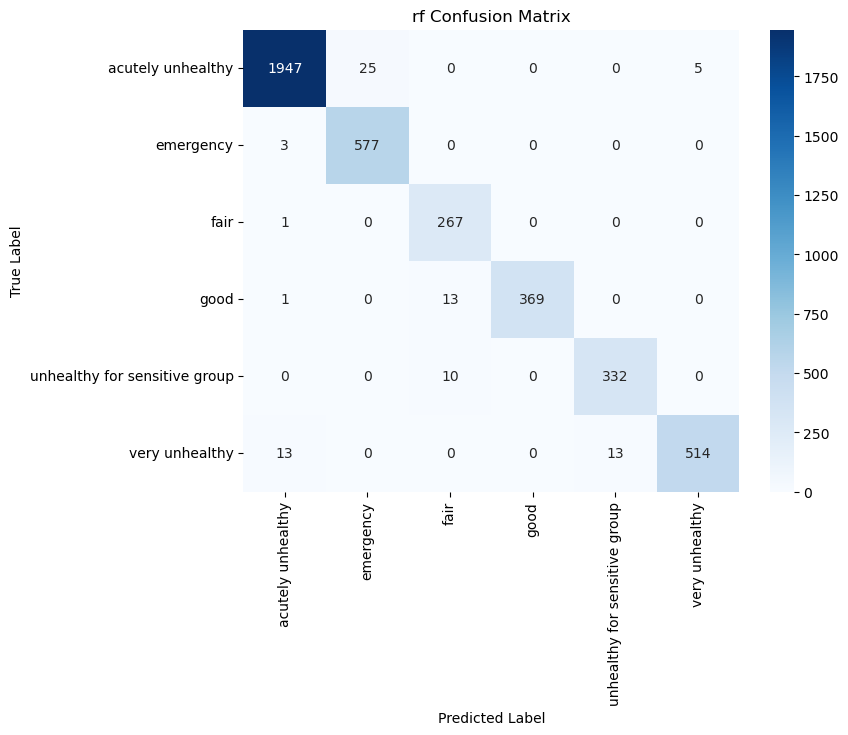

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Convert y_test from one-hot encoding to integer labels
y_test_labels = y_test

# 2. Generate the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_rf)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('rf Confusion Matrix')
plt.show()

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import joblib

# 1. Define the parameter search space for the Random Forest Classifier
param_dist_rf_clf = {
    'n_estimators': [100, 150, 200, 300, 400, 500],
    'max_depth': [None, 10, 15, 20, 25, 30],      # Max depth of trees
    'min_samples_split': [2, 5, 10,15],           # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],             # Minimum samples required at each leaf node
    'max_features': ['sqrt', 'log2', None],    # Number of features to consider at every split
    'bootstrap': [True, False]                 # Whether bootstrap samples are used when building trees
}

# 2. Initialize the baseline RandomForestClassifier
rf_clf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Configure the Randomized Search
print("Starting Hyperparameter Tuning for Random Forest Classifier...")
#rf_clf_search = RandomizedSearchCV(
    estimator=rf_clf_base,
    param_distributions=param_dist_rf_clf,
    n_iter=40,             # Evaluates 10 completely random setups
    cv=3,                  # 3-Fold Stratified Cross Validation
    scoring='accuracy',    # Optimize to maximize matching the teacher labels
    random_state=42,
    n_jobs=-1
)

# 4. Fit the search on your scaled training metrics and teacher pseudo-labels
rf_clf_search.fit(X_scaled, y_pseudo_train)

# 5. Extract and print the best model configuration
print("\n✅ Best Random Forest Classifier Parameters Found:")
print(rf_clf_search.best_params_)

best_rf_clf = rf_clf_search.best_estimator_

# 6. Evaluate on your scaled test set
X_test_scaled = scaler.transform(X_test)
y_pred_rf_clf = best_rf_clf.predict(X_test_scaled)

print("\n--- Tuned Distilled Random Forest Classifier Performance ---")
print(classification_report(y_test, y_pred_rf_clf, target_names=le.classes_, zero_division=0))



IndentationError: unexpected indent (2440697154.py, line 22)